In [4]:
import numpy as np
import matplotlib.pyplot as plt

from functions import registry, Cities
from algorithms import BlindSearch, HillClimbing, SimulatedAnnealing, GeneticAlgorithm, DifferentialEvolution, ParticleSwarmOptimizer, SOMA
from plots import surface_grid, plot_surface_and_path, plot_convergence, plot_neighbors_on_surface, plot_surface, plot_contour, plot_1d_slice, animate_best_path_on_heatmap, animate_tsp_history_cities, display_gif_frame_by_frame
from IPython.display import Image, display

### Function Visualization

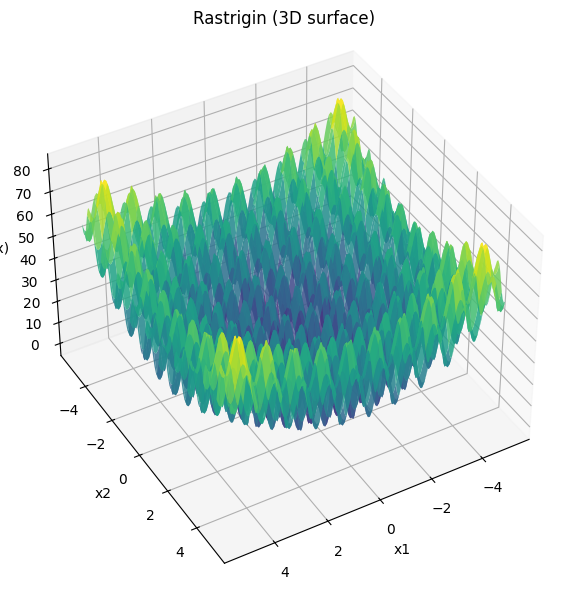

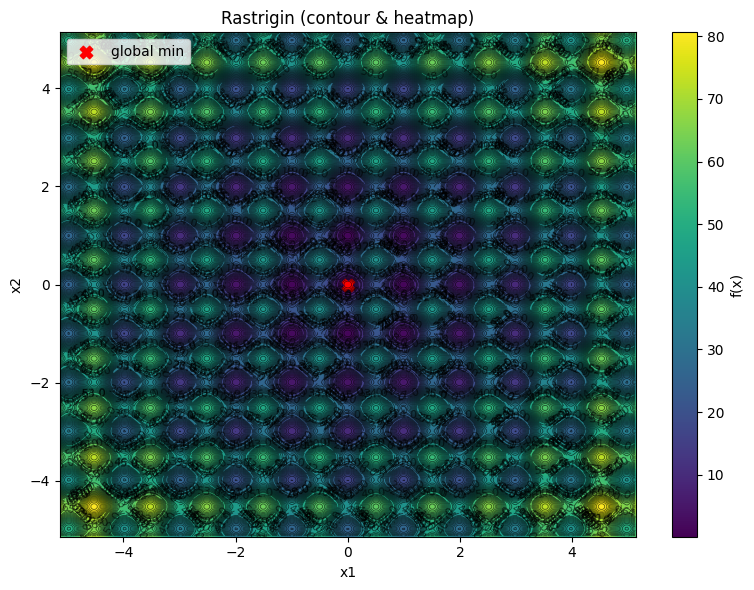

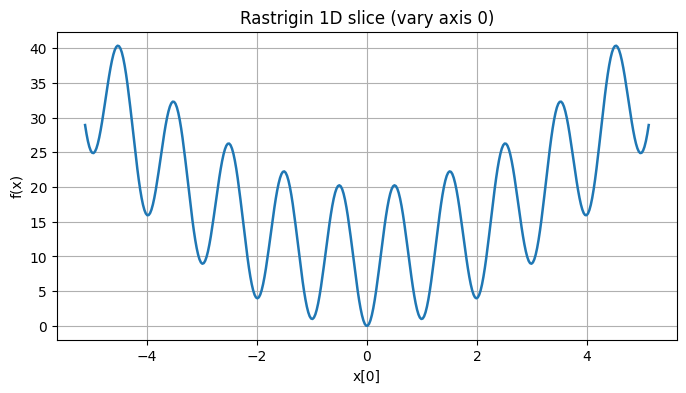

In [2]:
# funcs = ["Sphere", "Ackley", "Rastrigin", "Rosenbrock", "Griewank", "Schwefel", "Levy", "Michalewicz", "Zakharov"]
fn_name = "Rastrigin"
plot_surface(fn_name, grid=140, elev=40, azim=60)
plot_contour(fn_name, grid=300, levels=80)
plot_1d_slice(fn_name, axis=0)

### BlindSearch

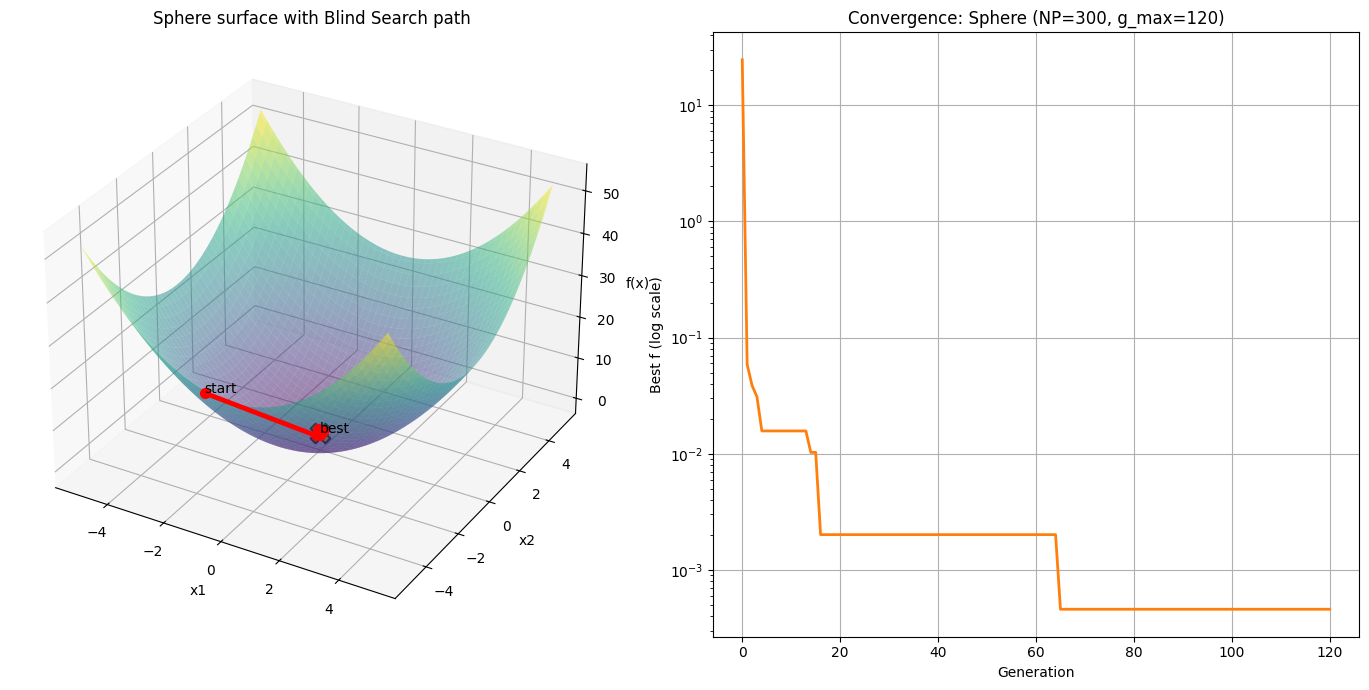

Best found: [ 0.00196659 -0.0213165 ] f = 0.00045826083880856904


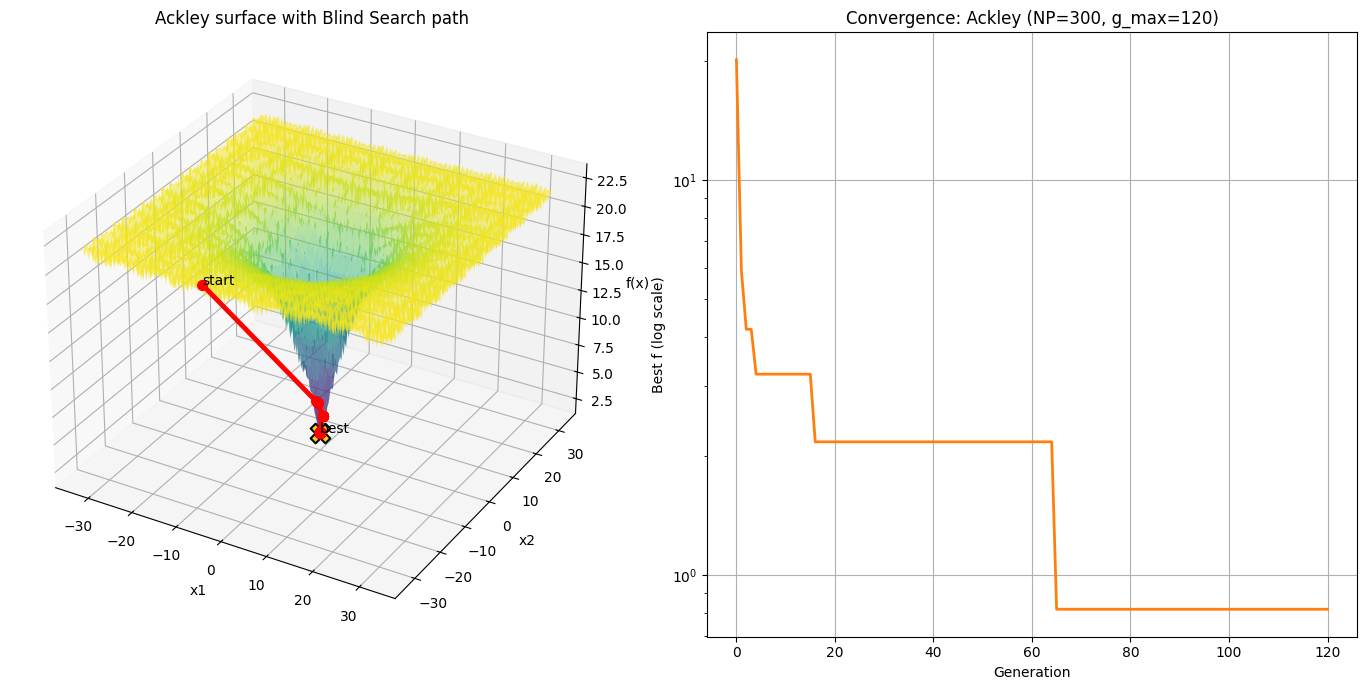

Best found: [ 0.01258616 -0.13642563] f = 0.8185350050829823


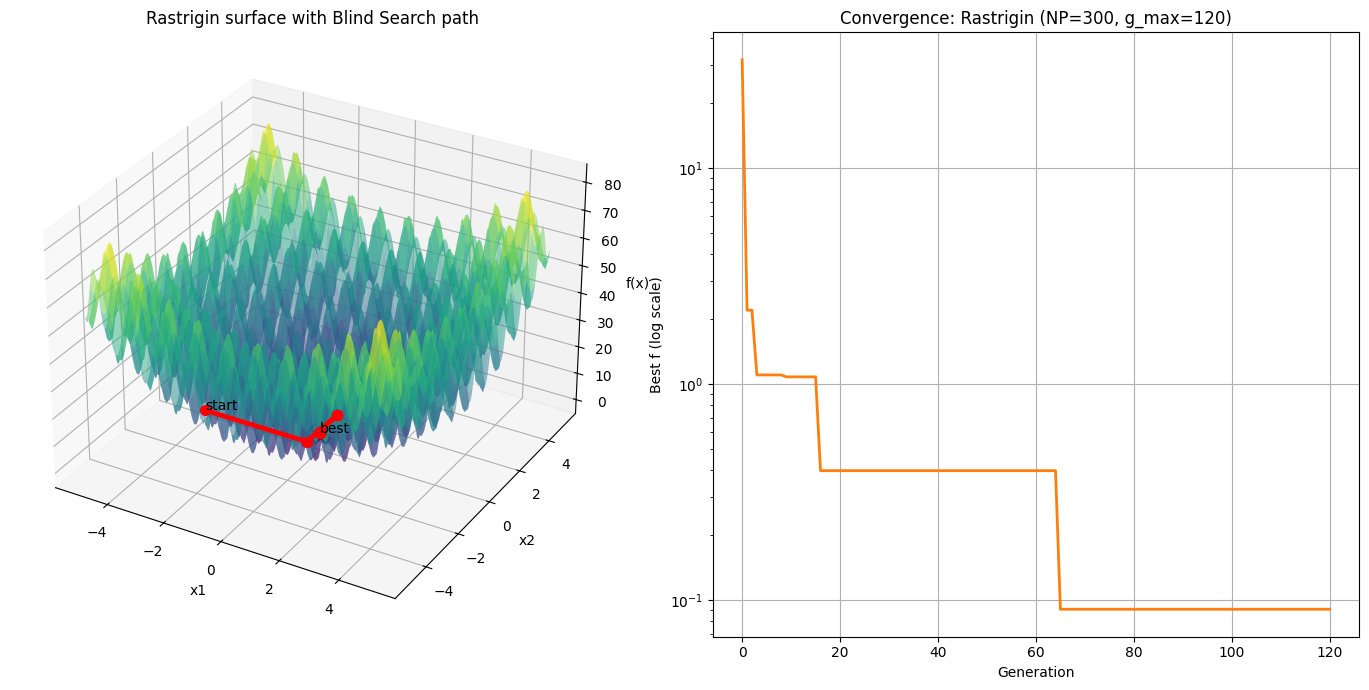

Best found: [ 0.00196659 -0.0213165 ] f = 0.09078131257441058


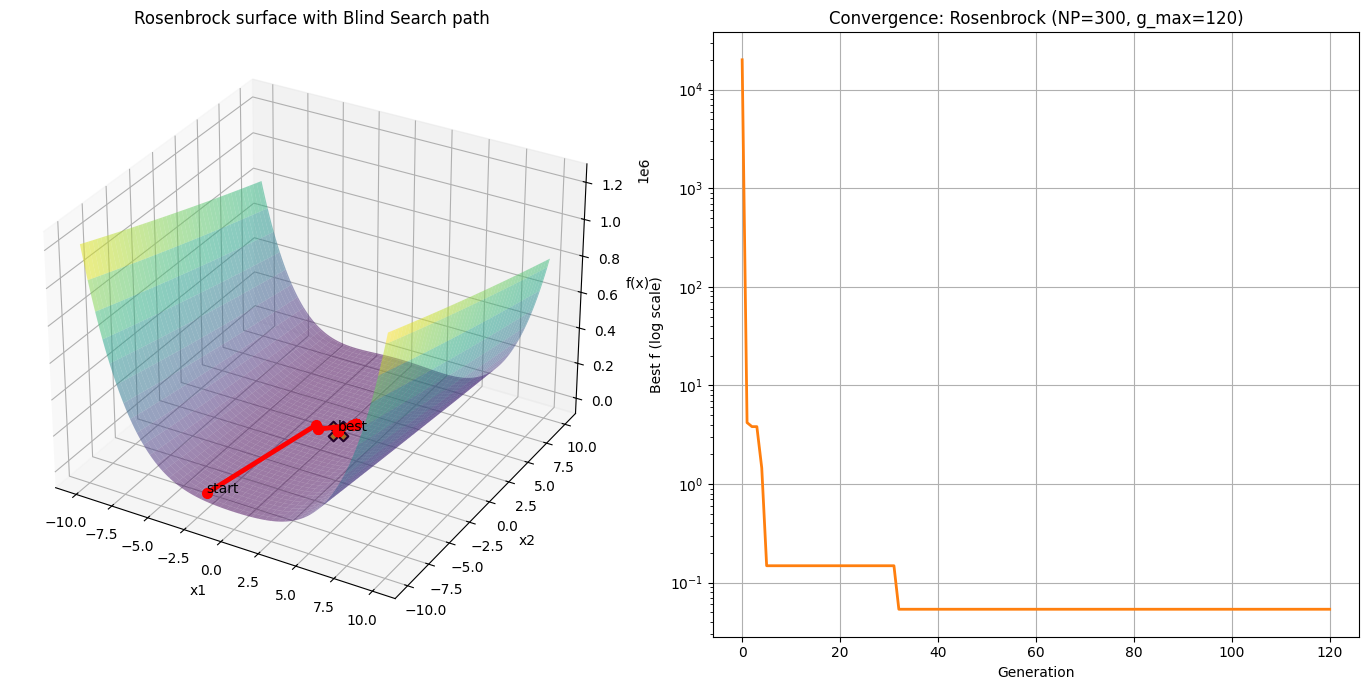

Best found: [0.8275094  0.70024656] f = 0.05369978592650232


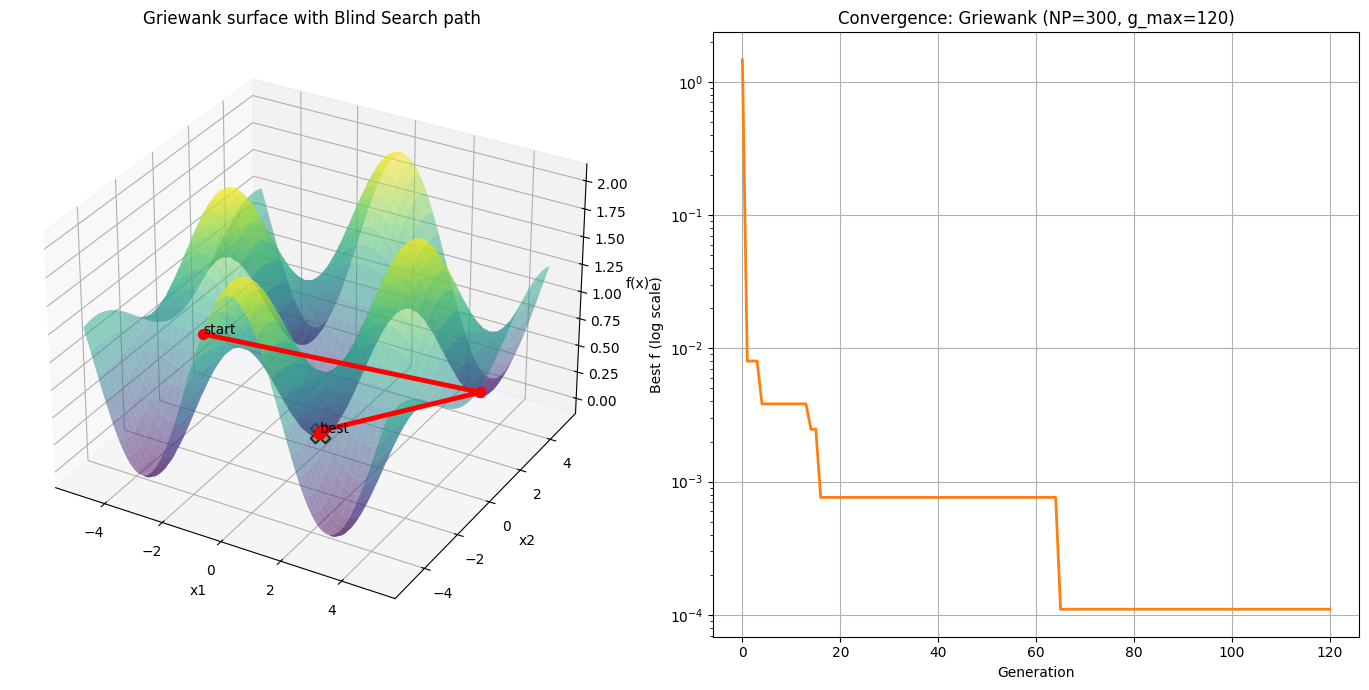

Best found: [ 0.0019205 -0.0208169] f = 0.00011028707594584741


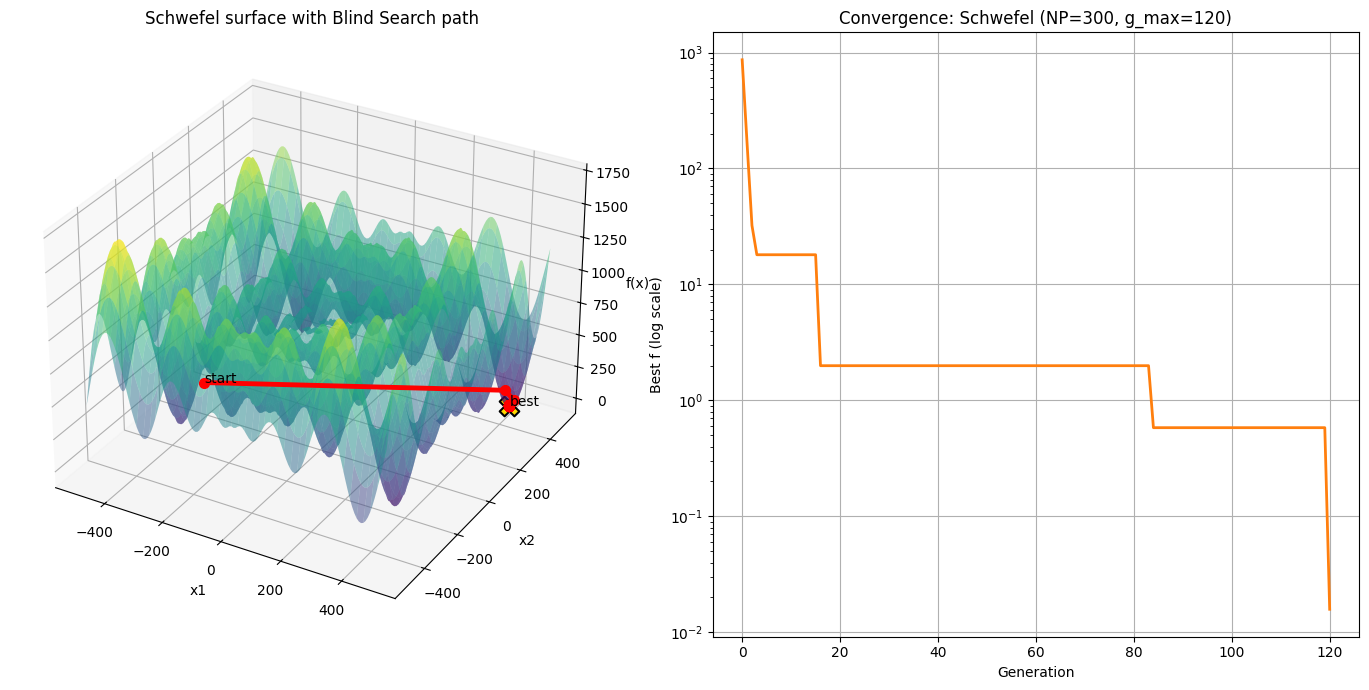

Best found: [420.70034041 421.1993023 ] f = 0.015822960617924764


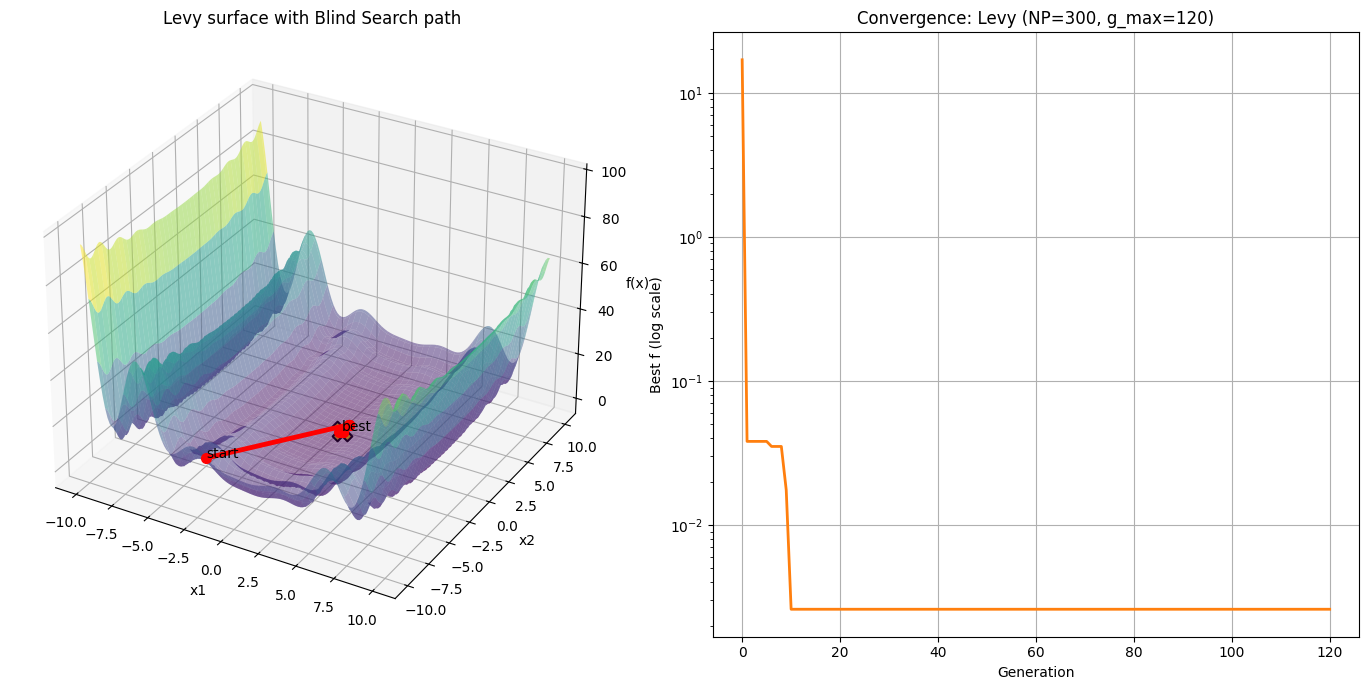

Best found: [1.00548184 0.8058663 ] f = 0.0026016141896642933


c:\Users\valeojan\OneDrive - Tietoevry\Desktop\ICCBI\reports\SCHOOL\BIA\plots.py:158: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


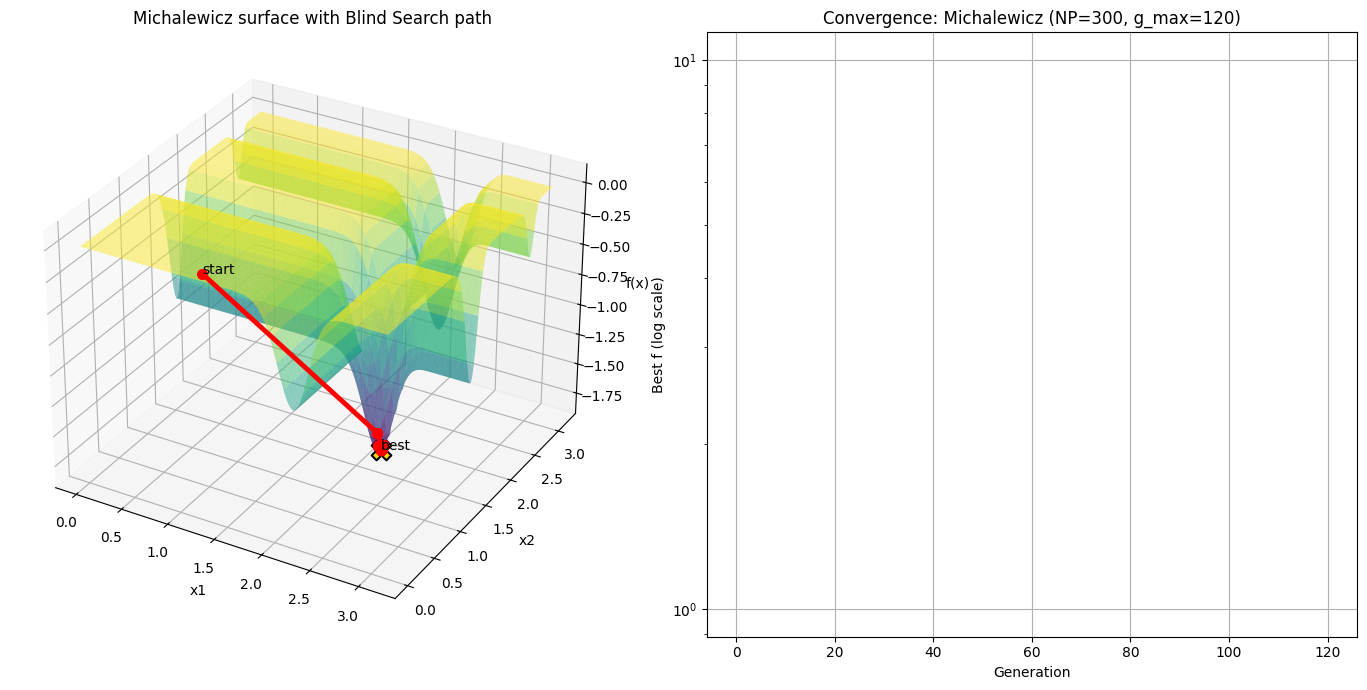

Best found: [2.22328924 1.57251255] f = -1.7943989358679646


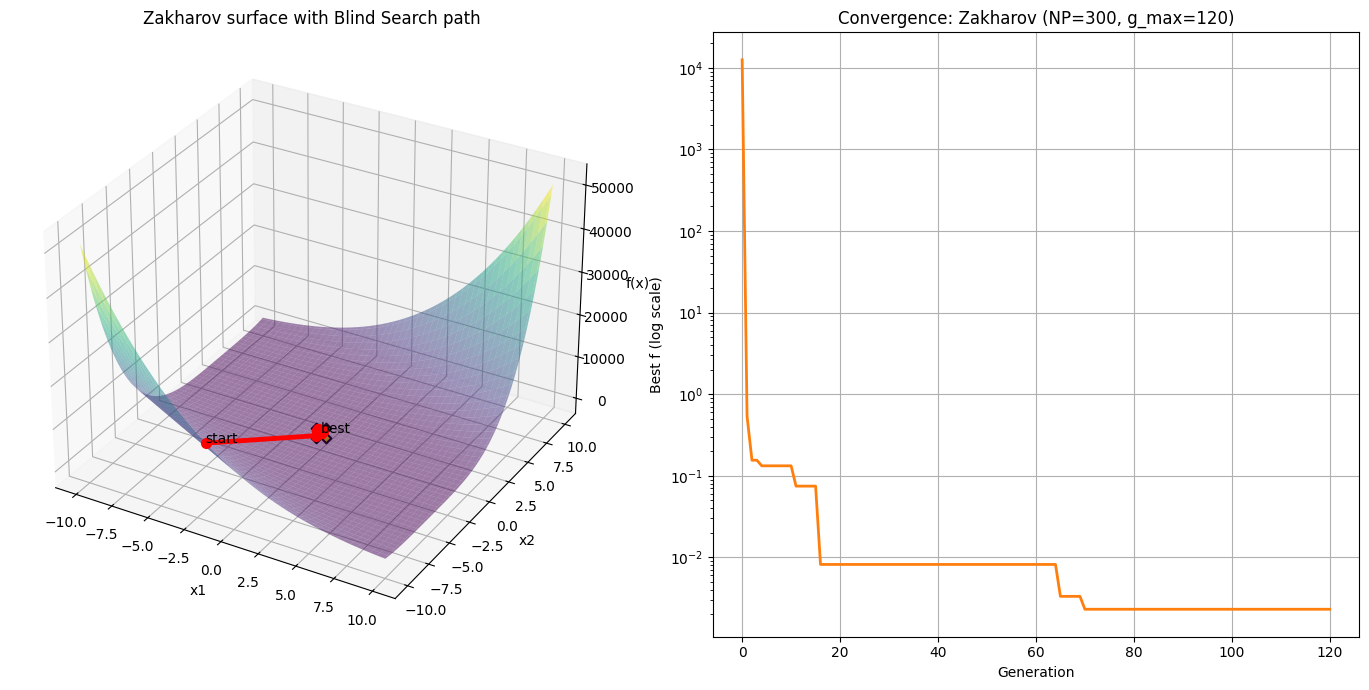

Best found: [ 0.03356147 -0.03125383] f = 0.0023126883489806255


In [3]:
funcs = ["Sphere", "Ackley", "Rastrigin", "Rosenbrock", "Griewank", "Schwefel", "Levy", "Michalewicz", "Zakharov"]

# parameters
NP = 300
g_max = 120
seed = 888
grid = 140

for fn_name in funcs:
    bf = registry[fn_name]
    lb, ub = bf.bounds

    # run blind search
    bs = BlindSearch(func=bf.func, bounds=(lb, ub), NP=NP, g_max=g_max, seed=seed)
    best_x, best_f, history = bs.run(record_history=True)

    # prepare surface grid
    X, Y, Z = surface_grid(bf.func, lb, ub, grid_points=grid)

    # plotting
    fig = plt.figure(figsize=(14, 7))
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')

    # plot surface with modest alpha (so path shows)
    plot_surface_and_path(ax1, X, Y, Z, path_points=np.array(history["best_x"]), surf_alpha=0.5)
    ax1.set_title(f"{fn_name} surface with Blind Search path")
    ax1.set_xlabel("x1"); ax1.set_ylabel("x2"); ax1.set_zlabel("f(x)")

    ax2 = fig.add_subplot(1, 2, 2)
    plot_convergence(ax2, history["best_f"])
    ax2.set_title(f"Convergence: {fn_name} (NP={NP}, g_max={g_max})")

    plt.tight_layout()
    plt.show()

    print("Best found:", best_x, "f =", best_f)

### HillClimb

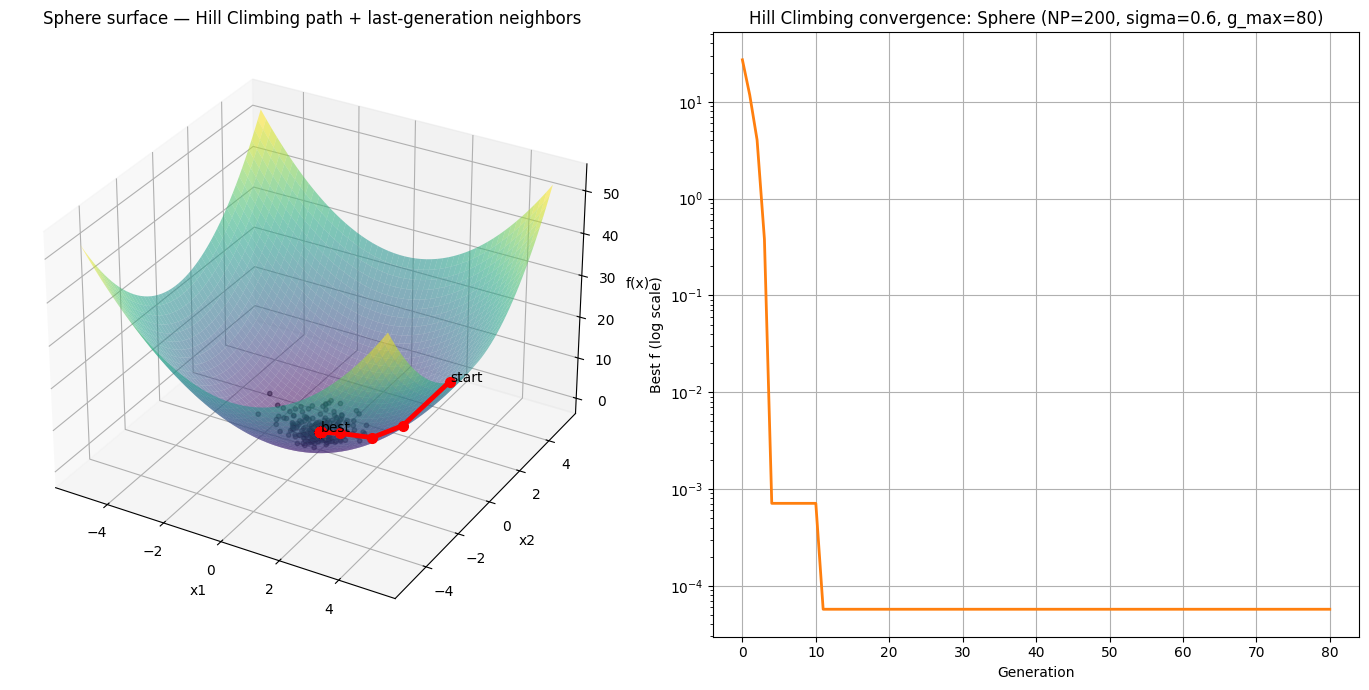

Best found: [ 0.00297845 -0.00695946] f = 5.730532318043135e-05


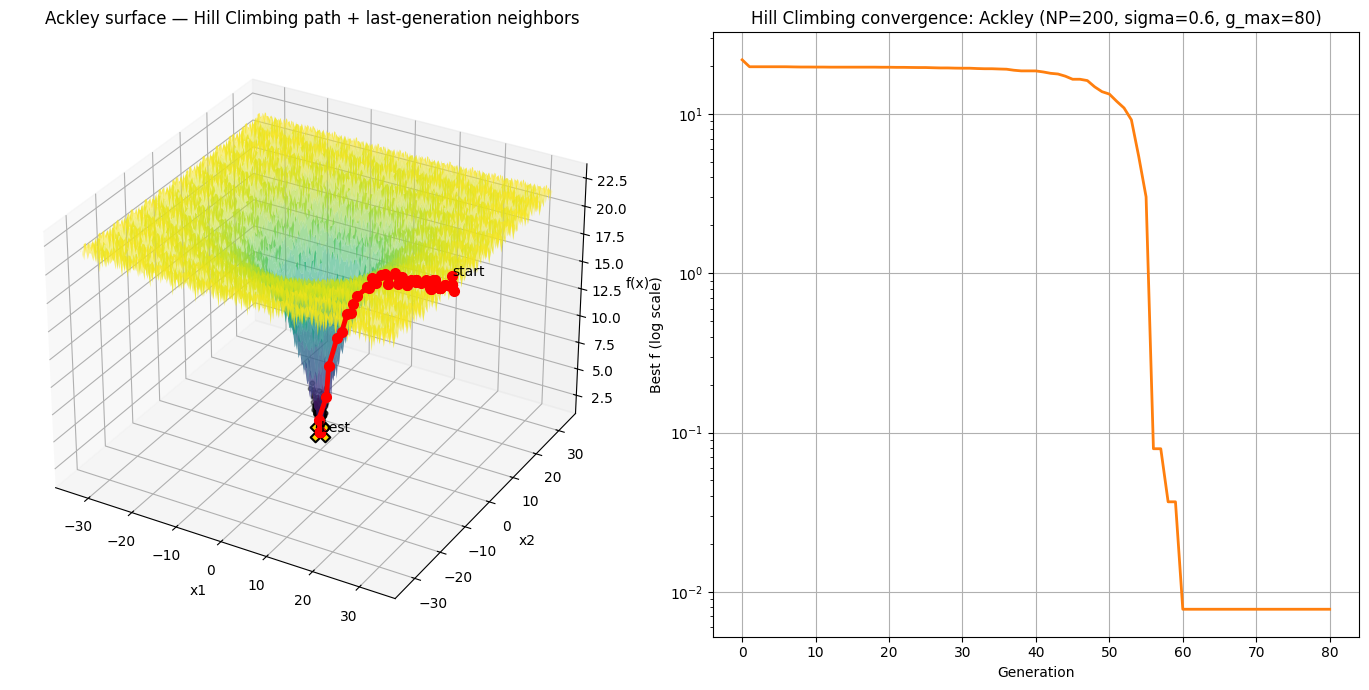

Best found: [-0.00243795  0.00111031] f = 0.007768085384740164


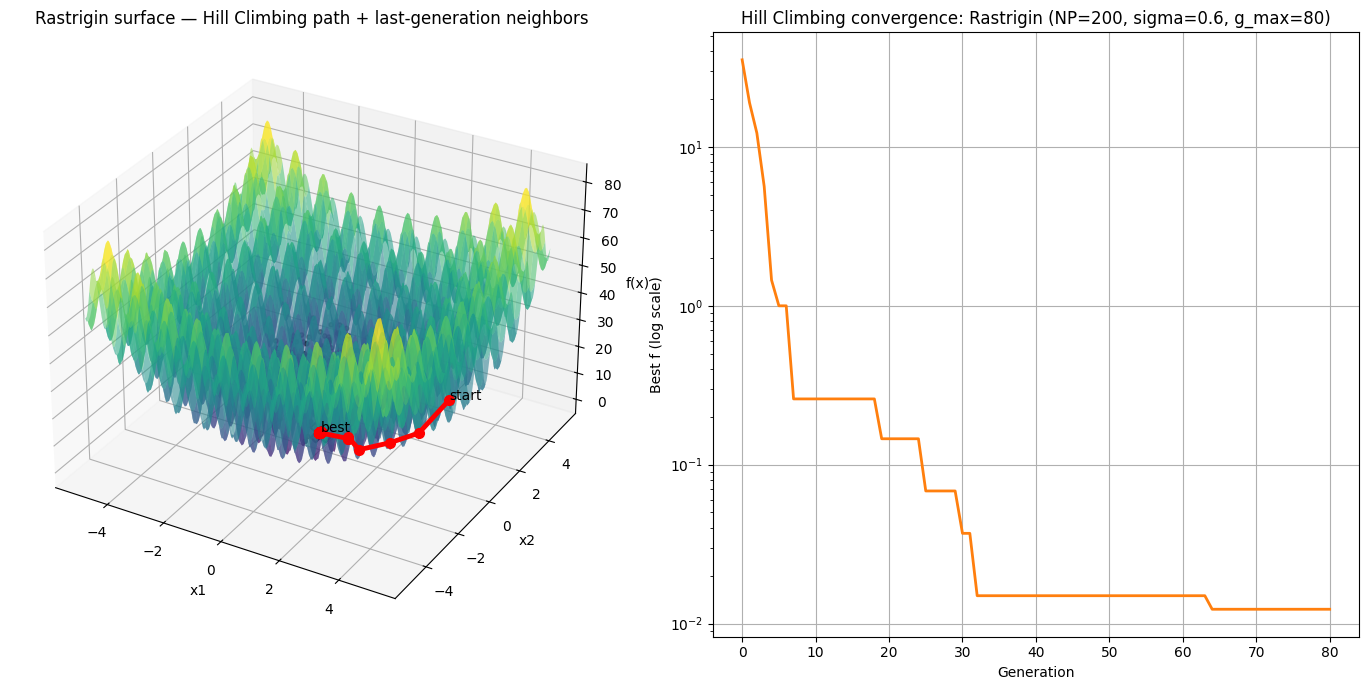

Best found: [ 0.00411818 -0.0067118 ] f = 0.012300312809085057


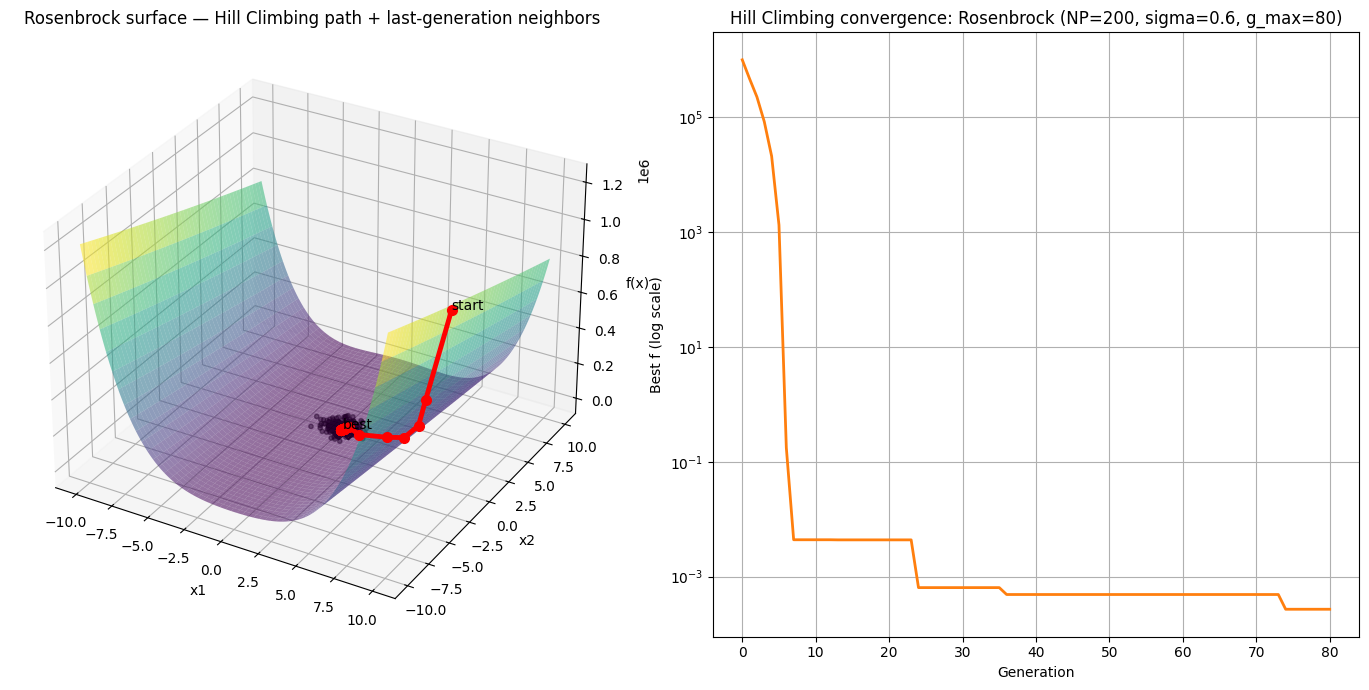

Best found: [0.98757929 0.97639097] f = 0.00027050750053430846


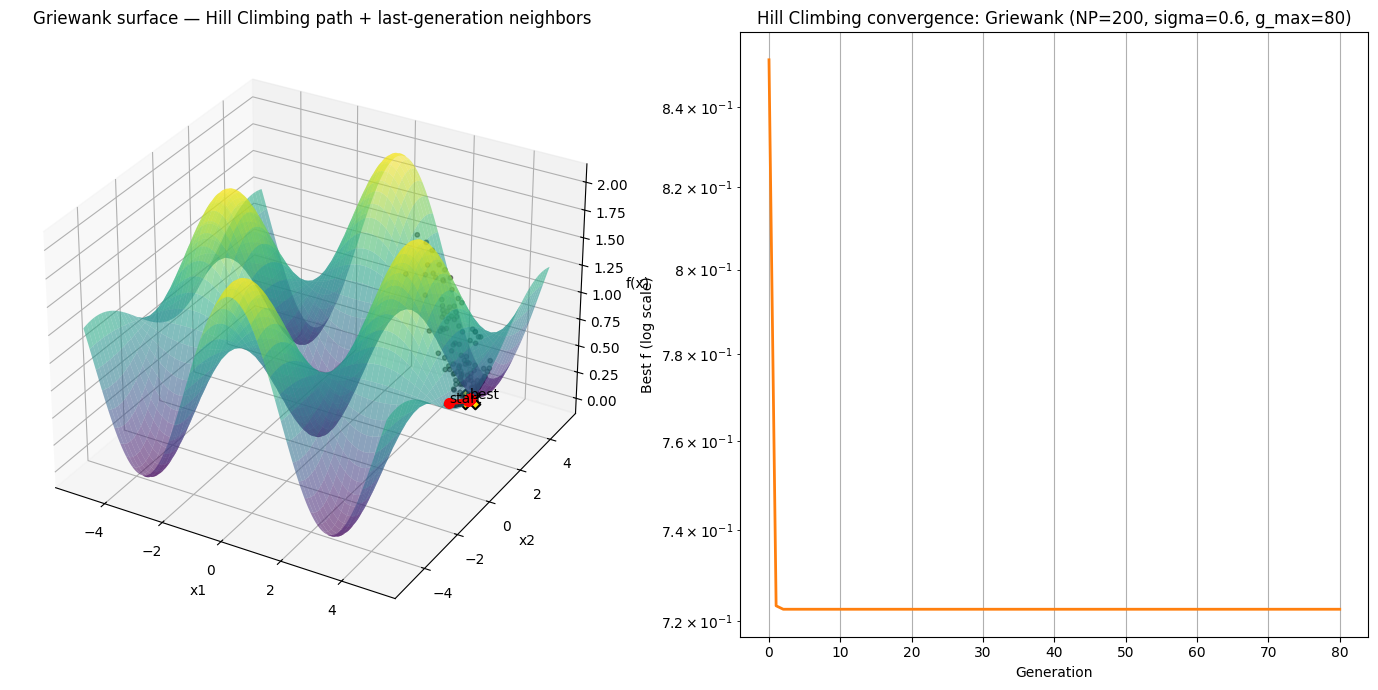

Best found: [5.00000000e+00 2.84245952e-05] f = 0.7225878145942726


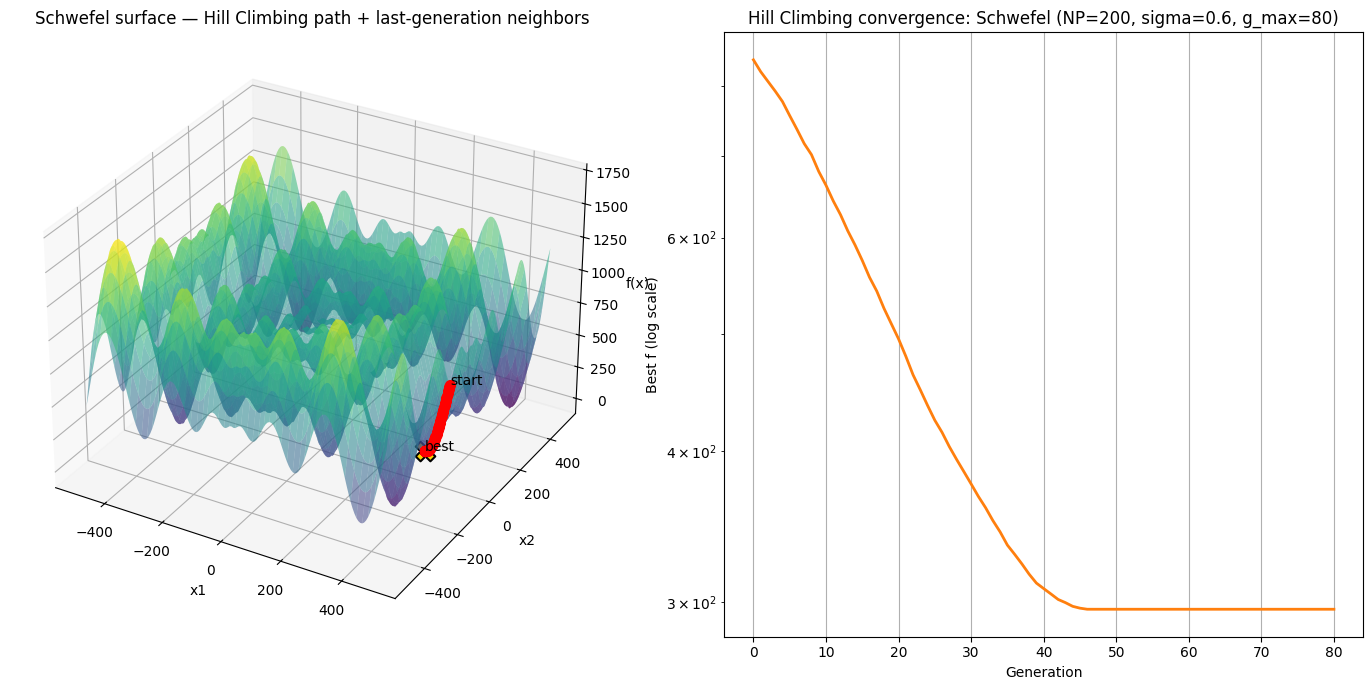

Best found: [ 420.97026705 -124.83544924] f = 296.10674429274286


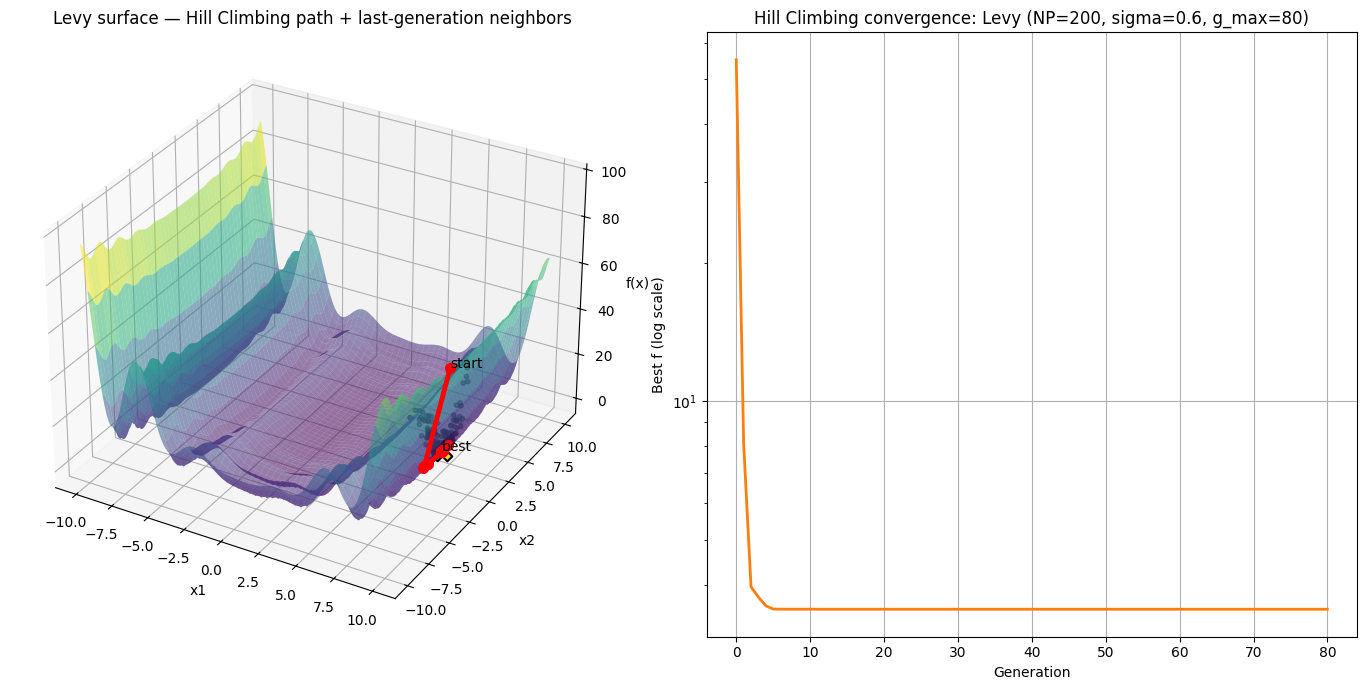

Best found: [7.72353313 0.99269684] f = 3.5359290326836064


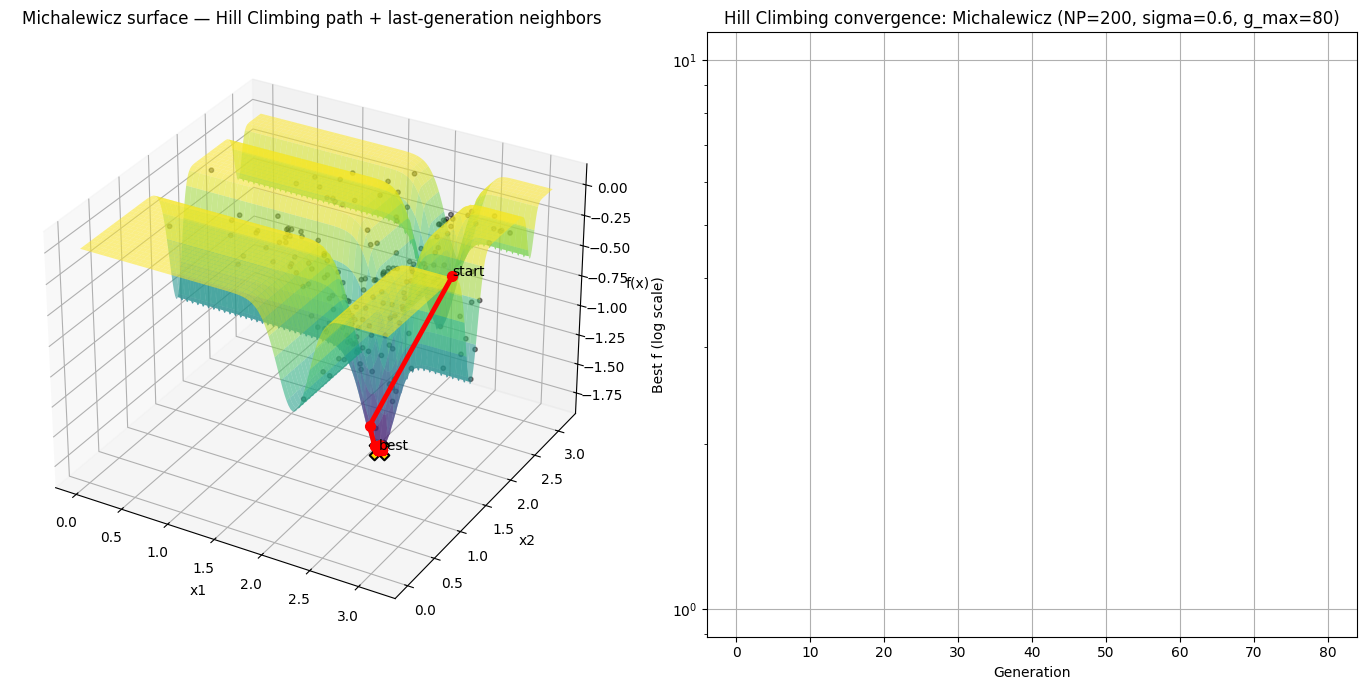

Best found: [2.20510594 1.56790698] f = -1.800887206842801


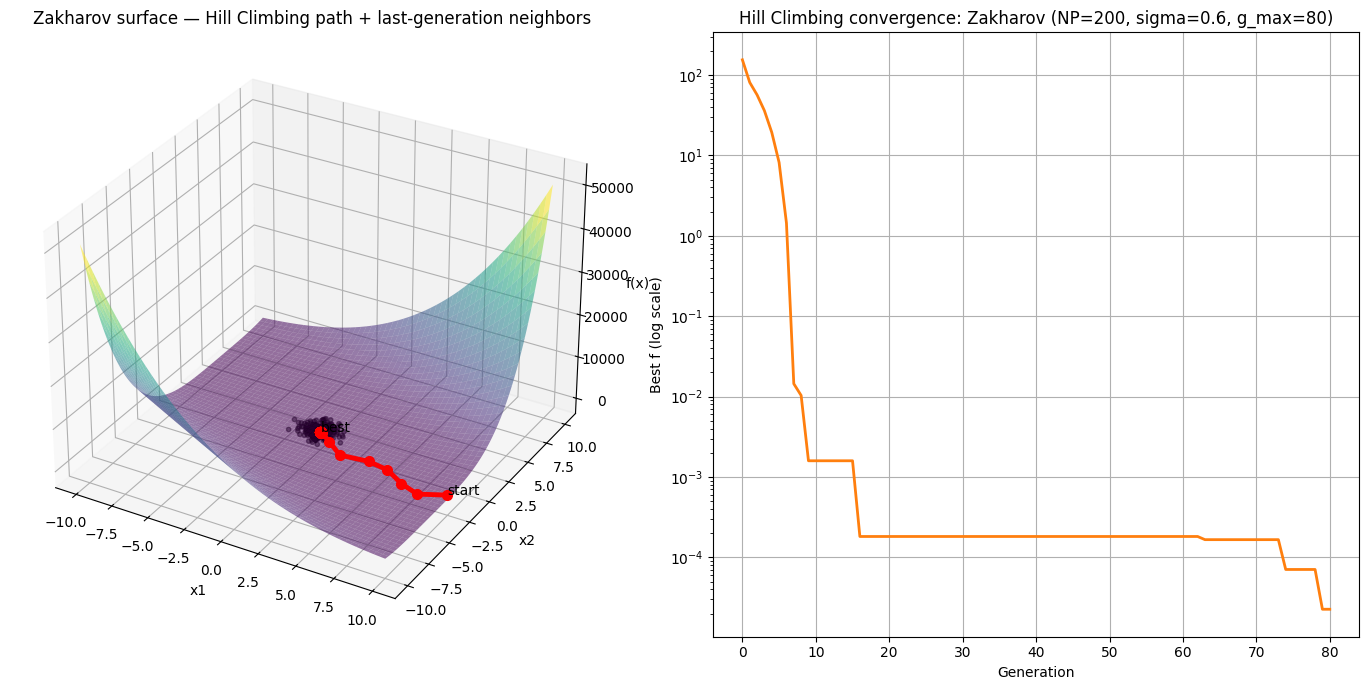

Best found: [0.00079456 0.00311109] f = 2.2618994586968735e-05


In [4]:
funcs = ["Sphere", "Ackley", "Rastrigin", "Rosenbrock", "Griewank", "Schwefel", "Levy", "Michalewicz", "Zakharov"]

# parameters
fn_name = "Rastrigin"
NP = 200            # neighbors per generation
g_max = 80          # generations
sigma = 0.6         # neighbor std dev (try different sizes: 0.1..1.5)
seed = 2025
grid = 160

for fn_name in funcs:
    bf = registry[fn_name]
    lb, ub = bf.bounds

    # run hill climbing
    hc = HillClimbing(func=bf.func, bounds=(lb, ub), NP=NP, sigma=sigma, g_max=g_max, seed=seed)
    best_x, best_f, history = hc.run(record_history=True)

    # prepare surface grid
    X, Y, Z = surface_grid(bf.func, lb, ub, grid_points=grid)

    # plotting - surface + path + last-generation neighbors
    fig = plt.figure(figsize=(14, 7))
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')

    # surface and path (path will be visible on top)
    plot_surface_and_path(ax1, X, Y, Z, path_points=np.array(history["best_x"]), surf_alpha=0.55)

    # plot neighbors of the last generation (history["sampled"][-1]) to see local search region
    last_neighbors = history["sampled"][-1]  # shape (NP, d)
    plot_neighbors_on_surface(ax1, X, Y, Z, last_neighbors, marker='o', markersize=10, alpha=0.45, color='black')

    ax1.set_title(f"{fn_name} surface — Hill Climbing path + last-generation neighbors")
    ax1.set_xlabel("x1"); ax1.set_ylabel("x2"); ax1.set_zlabel("f(x)")

    # convergence
    ax2 = fig.add_subplot(1, 2, 2)
    plot_convergence(ax2, history["best_f"])
    ax2.set_title(f"Hill Climbing convergence: {fn_name} (NP={NP}, sigma={sigma}, g_max={g_max})")

    plt.tight_layout()
    plt.show()

    print("Best found:", best_x, "f =", best_f)

### SimulatedAnnealing

Rastrigin SA best f: 0.010872290213903568 x: [ 0.00502517 -0.00543642]


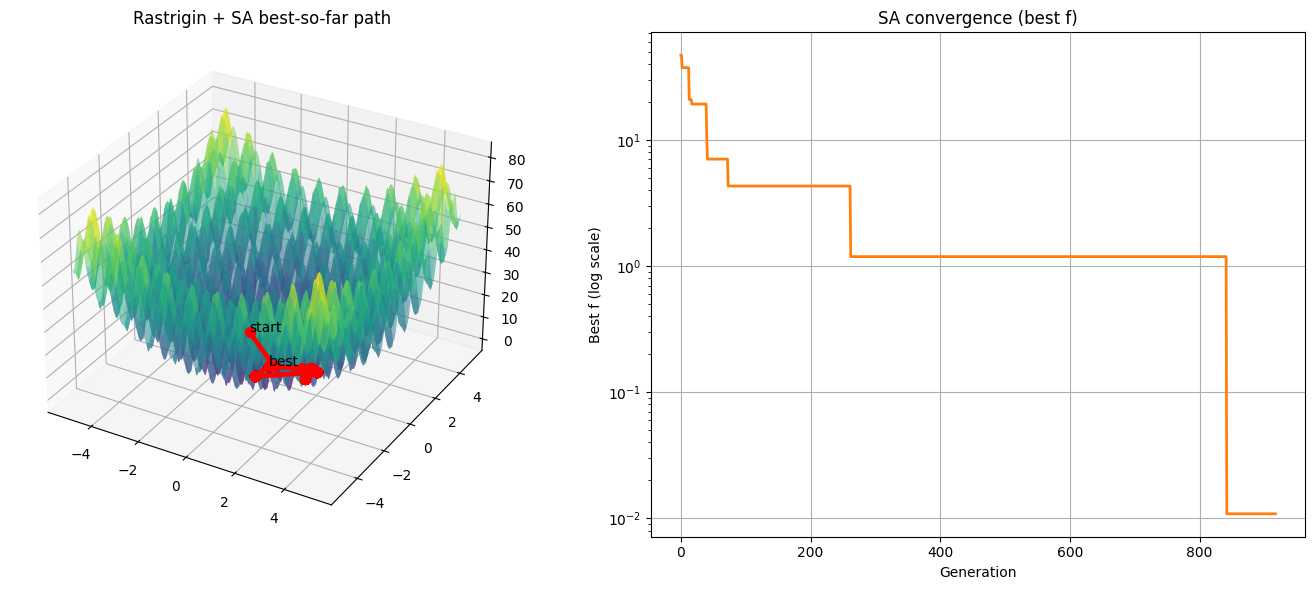

Acceptance rate (Rastrigin SA): 0.2410032715376227 iterations: 917


In [7]:
#funcs = ["Sphere", "Ackley", "Rastrigin", "Rosenbrock", "Griewank", "Schwefel", "Levy", "Michalewicz", "Zakharov"]
# parameters
bf2 = registry["Rastrigin"]
lb2, ub2 = bf2.bounds

sa_rast = SimulatedAnnealing(func=bf2.func, bounds=(lb2, ub2), T0=100.0, Tmin=0.01, alpha=0.99, sigma=0.6, max_iters=5000, seed=123)

x_best_r, f_best_r, hist_r = sa_rast.run(record_history=True)
print("Rastrigin SA best f:", f_best_r, "x:", x_best_r)

# Visualize Rastrigin surface + best-so-far path
X, Y, Z = surface_grid(bf2.func, lb2, ub2, grid_points=140)

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
plot_surface_and_path(ax1, X, Y, Z, path_points=np.array(hist_r['best_x']), surf_alpha=0.55)
ax1.set_title("Rastrigin + SA best-so-far path")

ax2 = fig.add_subplot(1, 2, 2)
plot_convergence(ax2, hist_r['best_f'])
ax2.set_title("SA convergence (best f)")
plt.tight_layout()
plt.show()

# Optional: print acceptance rate
accepted = np.array(hist_r['accepted'], dtype=int)
print("Acceptance rate (Rastrigin SA):", accepted.mean(), "iterations:", len(accepted))

Animation saved to: anim.gif


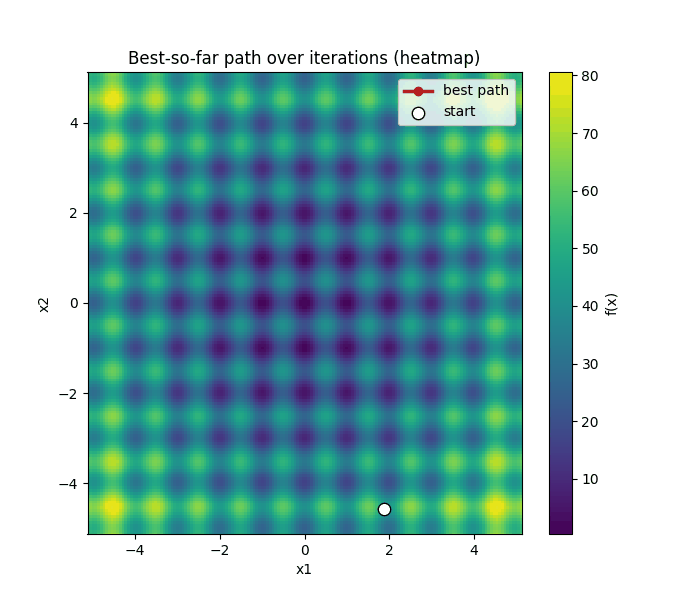

In [ ]:
from collections import OrderedDict

func = bf2.func
lb, ub = bf2.bounds
best_xs = hist_r["best_x"]
unique_best_xs = list(OrderedDict.fromkeys(tuple(x) for x in best_xs))
best_xs = [np.array(x) for x in unique_best_xs]

gif = animate_best_path_on_heatmap(func, lb, ub, best_xs,
                                   grid=160, interval=500,
                                   save_path="anim.gif")

display(Image(gif))

### Genetic algorithm

In [2]:
cities = Cities(n=40, seed=123, grid_size=1.0)
ga = GeneticAlgorithm(cities, NP=200, G=1000, mutation_prob=0.5, max_mutation_strength=0.1, seed=123)
best_tour, best_len, history = ga.run(record_history=True)
print("Best length (Cities GA):", best_len)
print("Best tour (Cities GA):", best_tour)
gif = animate_tsp_history_cities(cities, history["best_tour"], save_path="tsp_ga_cities_demo.gif", interval=150)
display_gif_frame_by_frame(gif, width=700)

Best length (Cities GA): 5.158710925152599
Best tour (Cities GA): [35 36 19 21 29 16  2 20 37 26 22 25  1 10 23 12 32  0  5 39 24 31 27 17
  6  8  3 34  9  7 28 14 15  4 18 38 30 13 33 11]
Saved: tsp_ga_cities_demo.gif


### DifferentialEvolution

Rastrigin best f = 0, best x = [-1.26253729e-09 -2.66036376e-09]


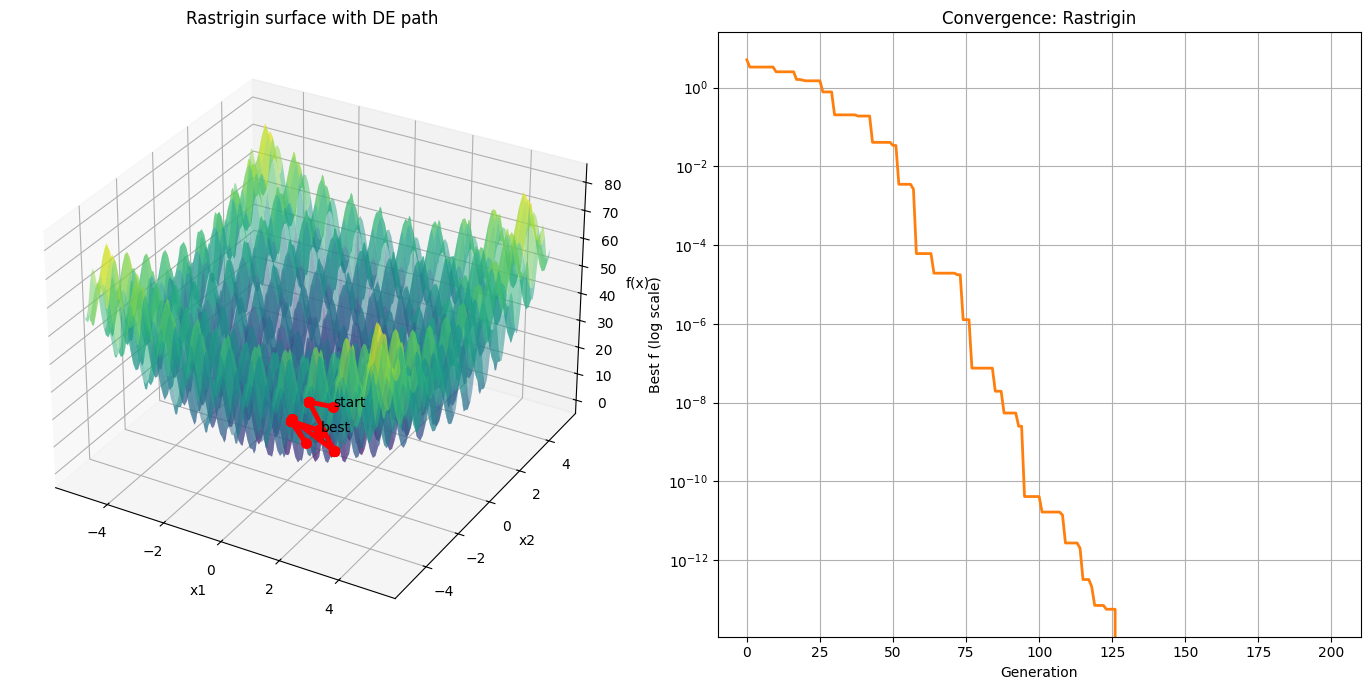

Animation saved to: anim.gif


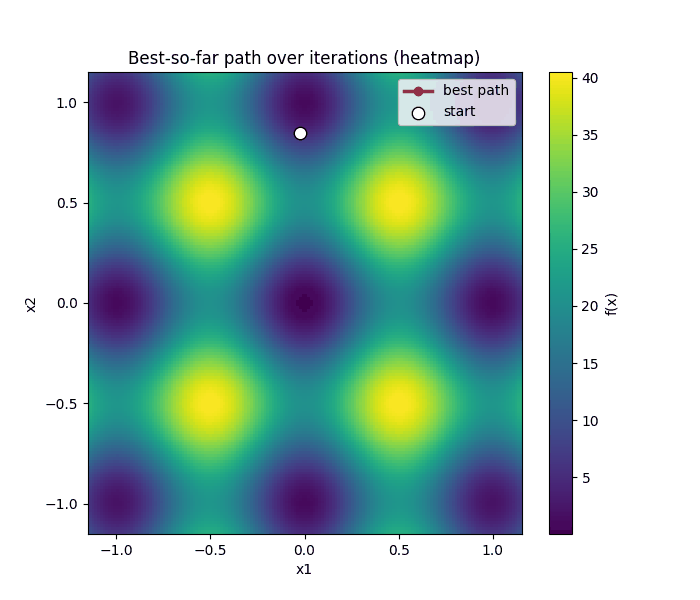

In [18]:
#funcs = ["Sphere", "Ackley", "Rastrigin", "Rosenbrock", "Griewank", "Schwefel", "Levy", "Michalewicz", "Zakharov"]
fn_name = "Rastrigin"
bf = registry[fn_name]
lb, ub = bf.bounds

# run blind search
de = DifferentialEvolution(func=bf.func, bounds=(lb, ub), NP=60, F=0.8, CR=0.9, g_max=200, seed=123)
best_x, best_f, history = de.run(record_history=True)
print(f"{fn_name} best f = {best_f:.6g}, best x = {best_x}")

# prepare surface grid
X, Y, Z = surface_grid(bf.func, lb, ub, grid_points=120)

# plotting
fig = plt.figure(figsize=(14, 7))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# plot surface with modest alpha (so path shows)
plot_surface_and_path(ax1, X, Y, Z, path_points=np.array(history["best_x"]), surf_alpha=0.5)
ax1.set_title(f"{fn_name} surface with DE path")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("f(x)")

ax2 = fig.add_subplot(1, 2, 2)
plot_convergence(ax2, history["best_f"])
ax2.set_title(f"Convergence: {fn_name}")

plt.tight_layout()
plt.show()

# animation
all_best_x = np.array(history["best_x"])
max_abs = np.max(np.abs(all_best_x))
ub = np.full(lb.shape, max_abs * 1.1)
lb = -ub
unique_best_xs = list(OrderedDict.fromkeys(tuple(x) for x in history["best_x"]))
best_xs = [np.array(x) for x in unique_best_xs]
gif = animate_best_path_on_heatmap(bf.func, lb, ub, best_xs, grid=160, interval=500, save_path="anim.gif")
display(Image(gif))

### ParticleSwarmOptimizer

Rastrigin best f = 0, best x = [-9.94271349e-10  2.22500565e-09]


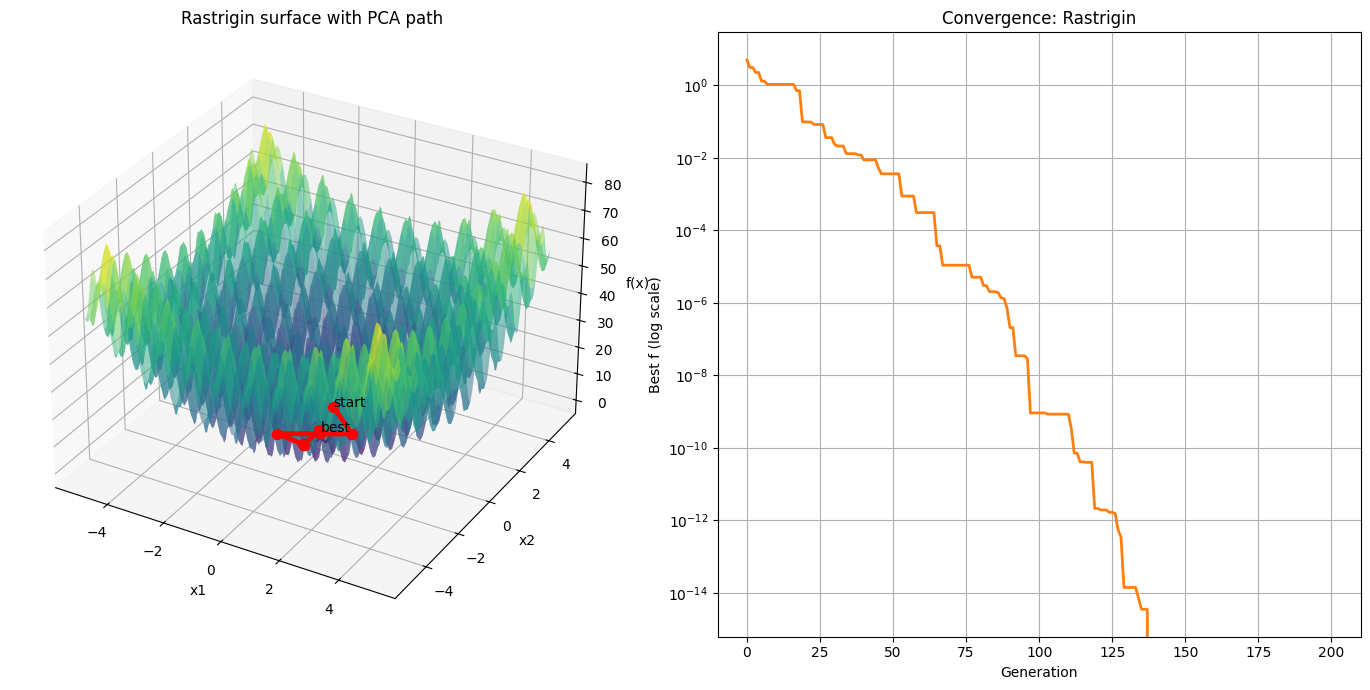

Animation saved to: anim.gif


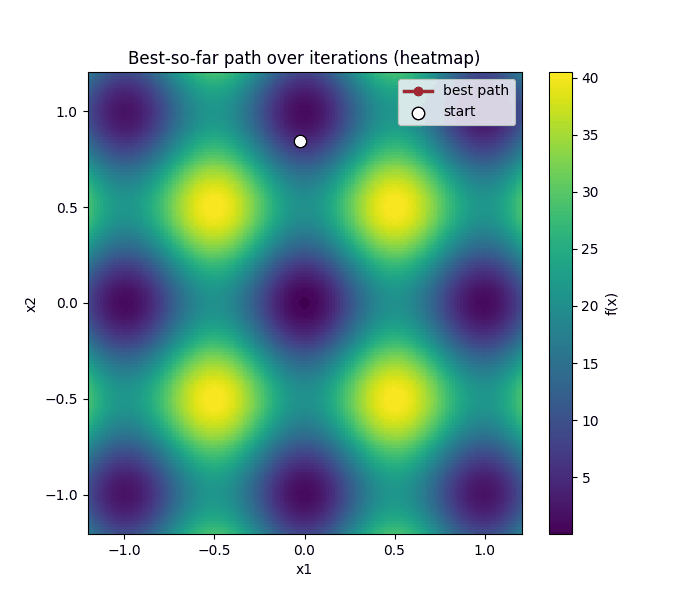

In [5]:
#funcs = ["Sphere", "Ackley", "Rastrigin", "Rosenbrock", "Griewank", "Schwefel", "Levy", "Michalewicz", "Zakharov"]
fn_name = "Rastrigin"
bf = registry[fn_name]
lb, ub = bf.bounds

# run blind search
PCA = ParticleSwarmOptimizer(func=bf.func, bounds=(lb, ub), pop_size=100, w=(0.9, 0.4), c1=1.5, c2=1.5, v_max=None, max_iter=200, w_decay=True, seed=123)
best_x, best_f, history = PCA.run(record_history=True)
print(f"{fn_name} best f = {best_f:.6g}, best x = {best_x}")

# prepare surface grid
X, Y, Z = surface_grid(bf.func, lb, ub, grid_points=120)

# plotting
fig = plt.figure(figsize=(14, 7))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# plot surface with modest alpha (so path shows)
plot_surface_and_path(ax1, X, Y, Z, path_points=np.array(history["best_x"]), surf_alpha=0.5)
ax1.set_title(f"{fn_name} surface with PCA path")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("f(x)")

ax2 = fig.add_subplot(1, 2, 2)
plot_convergence(ax2, history["best_f"])
ax2.set_title(f"Convergence: {fn_name}")

plt.tight_layout()
plt.show()

# animation
all_best_x = np.array(history["best_x"])
max_abs = np.max(np.abs(all_best_x))
ub = np.full(lb.shape, max_abs * 1.1)
lb = -ub
unique_best_xs = list(OrderedDict.fromkeys(tuple(x) for x in history["best_x"]))
best_xs = [np.array(x) for x in unique_best_xs]
gif = animate_best_path_on_heatmap(bf.func, lb, ub, best_xs, grid=160, interval=500, save_path="anim.gif")
display(Image(gif))

### SOMA

Rastrigin best f = 0, best x = [-7.10064666e-10  3.07051197e-09]


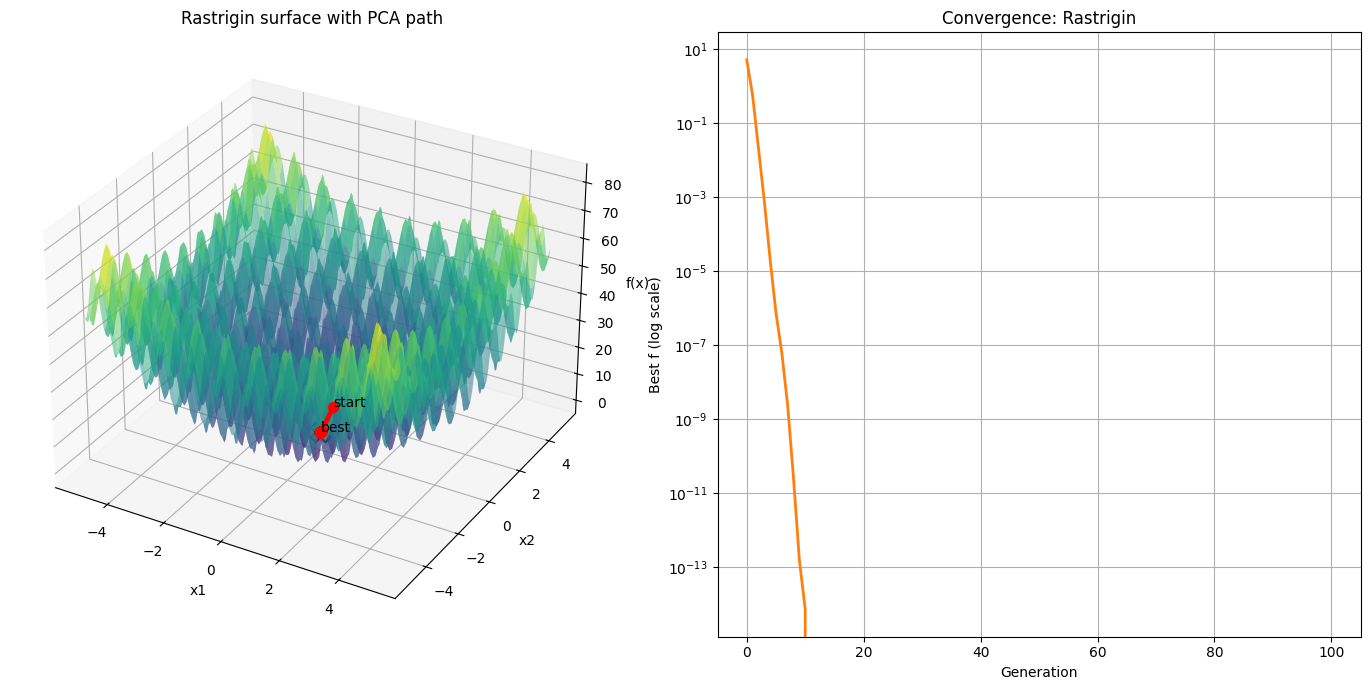

Animation saved to: anim.gif


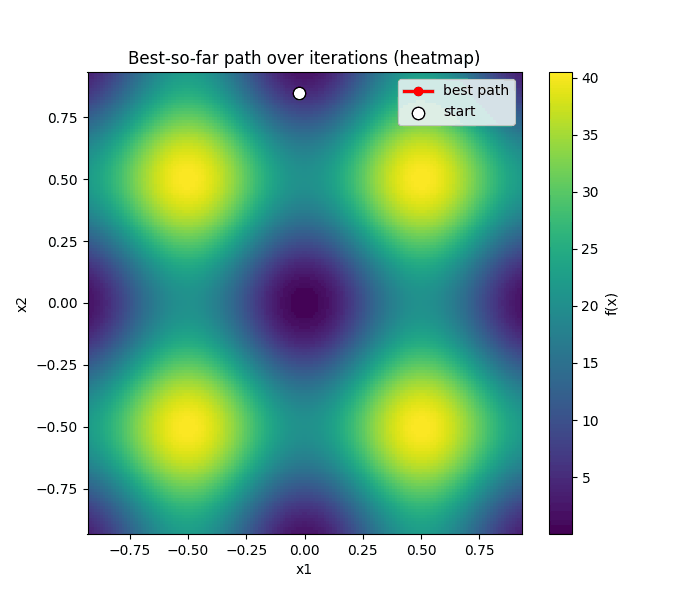

In [5]:
#funcs = ["Sphere", "Ackley", "Rastrigin", "Rosenbrock", "Griewank", "Schwefel", "Levy", "Michalewicz", "Zakharov"]
fn_name = "Rastrigin"
bf = registry[fn_name]
lb, ub = bf.bounds

# run blind search
SOMA = SOMA(func=bf.func, bounds=(lb, ub), NP=50, step=0.11, PRT=0.4, path_length=3.0, migrations=100, seed=123)
best_x, best_f, history = SOMA.run(record_history=True)
print(f"{fn_name} best f = {best_f:.6g}, best x = {best_x}")

# prepare surface grid
X, Y, Z = surface_grid(bf.func, lb, ub, grid_points=120)

# plotting
fig = plt.figure(figsize=(14, 7))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# plot surface with modest alpha (so path shows)
plot_surface_and_path(ax1, X, Y, Z, path_points=np.array(history["best_x"]), surf_alpha=0.5)
ax1.set_title(f"{fn_name} surface with PCA path")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("f(x)")

ax2 = fig.add_subplot(1, 2, 2)
plot_convergence(ax2, history["best_f"])
ax2.set_title(f"Convergence: {fn_name}")

plt.tight_layout()
plt.show()

# animation
all_best_x = np.array(history["best_x"])
max_abs = np.max(np.abs(all_best_x))
ub = np.full(lb.shape, max_abs * 1.1)
lb = -ub
unique_best_xs = list(OrderedDict.fromkeys(tuple(x) for x in history["best_x"]))
best_xs = [np.array(x) for x in unique_best_xs]
gif = animate_best_path_on_heatmap(bf.func, lb, ub, best_xs, grid=160, interval=500, save_path="anim.gif")
display(Image(gif))